In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.least_squares import LinearRegression, PowerLawRegression
from src.SGD import SGD, NoisyGD
from scheduled import WSDSchedule, ConstantSchedule
from src.new_schedules.polynomial import PolynomialSchedule
from src.compute import Computations

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\compute.py:225: SyntaxWarning: invalid escape sequence '\e'
  label=f'Optimum: $\eta \\approx {best_eta:.2e}$')
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\compute.py:226: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Base Learning Rate ($\eta$)')
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\compute.py:227: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Final Risk $\mathbb{E}[f(x_T) - f^*]$')
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\compute.py:228: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f"$\eta$ optimization for schedule={self.schedules_names[i_schedule]}")
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\compute.py:259: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f"Minimum Risk at optimal $\eta$ for different $t$ values")
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\compute.py:266: SyntaxWarning: invalid escape sequence '\e'
  pl

In [2]:
T=100
sigma = 0.1
dim = 10

eta = 0.1

model = PowerLawRegression(dim=dim, sigma=sigma, exponent=2)

wsd = WSDSchedule(steps=T, base_lr=eta, cooldown_len=0.4)
constant = ConstantSchedule(steps=T, base_lr=eta)
polynomial = PolynomialSchedule(steps=T, base_lr=eta, exponent=0.5)

In [3]:
n = 1000
x0 = np.random.multivariate_normal(np.zeros(dim), np.eye(dim))

computations_noisyGD = Computations(model, schedules=[polynomial, wsd, constant], sgd_class=NoisyGD)
computations_SGD = Computations(model, schedules=[polynomial, wsd, constant], sgd_class=SGD)

#empirical = computations_noisyGD.compute_all_empirical_risks(x0, n_runs=n, plot=True)
#theoretical = computations_noisyGD.compute_all_theoretical_risks(x0, plot=True)
#empirical_SGD = computations_SGD.compute_all_empirical_risks(x0, n_runs=n, plot=True)
#theoretical_SGD = computations_SGD.compute_all_theoretical_risks(x0, plot=True)

risksNoisy = computations_noisyGD.compute_all_risks(x0, n_runs=n, plot=True)
risksSGD = computations_SGD.compute_all_risks(x0, n_runs=n, plot=True)
approx_vs_theoretical = computations_SGD.compute_approx_vs_theoretical_risks(x0, plot=True, log_scale=True)
...

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\compute.py:225: SyntaxWarning: invalid escape sequence '\e'
  label=f'Optimum: $\eta \\approx {best_eta:.2e}$')
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\compute.py:226: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Base Learning Rate ($\eta$)')
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\compute.py:227: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Final Risk $\mathbb{E}[f(x_T) - f^*]$')
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\compute.py:228: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f"$\eta$ optimization for schedule={self.schedules_names[i_schedule]}")
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\compute.py:259: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f"Optimal $\eta$ and Minimum Risk at different $t$ values")
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\compute.py:266: SyntaxWarning: invalid escape sequence '\e'
  pl

KeyboardInterrupt: 

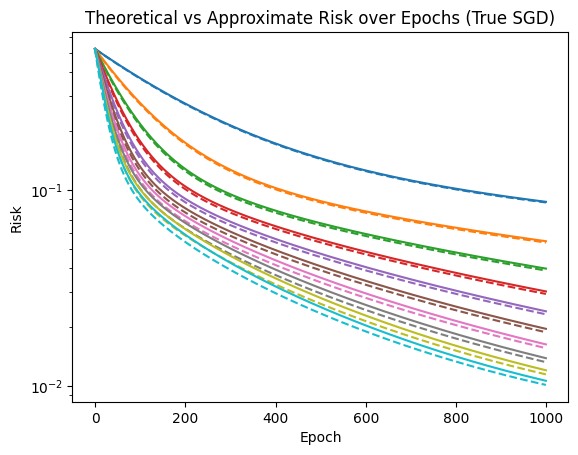

In [ ]:
n = 100
x0 = np.random.multivariate_normal(np.zeros(dim), np.eye(dim))
T = 1000

schedules = [ConstantSchedule(steps=T, base_lr=eta) for eta in np.linspace(0.01, 0.1, num=10)]
schedules_names = [f"ConstantSchedule(eta={eta:.2f})" for eta in np.linspace(0.01, 0.1, num=10)]
computations_SGD_many = Computations(model, schedules=schedules, schedules_names=schedules_names, sgd_class=SGD)
all = computations_SGD_many.compute_approx_vs_theoretical_risks(x0,  plot=True, log_scale=True, legend=False)


## Optim $\eta$

In [3]:
T=100
sigma = 0.1
dim = 10

eta = 0.1
n = 1000

model = PowerLawRegression(dim=dim, sigma=sigma, exponent=2)

wsd = WSDSchedule(steps=T, base_lr=eta, cooldown_len=0.4)
constant = ConstantSchedule(steps=T, base_lr=eta)
polynomial = PolynomialSchedule(steps=T, base_lr=eta, exponent=0.5)

computations_SGD = Computations(model, schedules=[polynomial, wsd, constant], sgd_class=SGD)
x0 = np.random.multivariate_normal(np.zeros(dim), np.eye(dim))

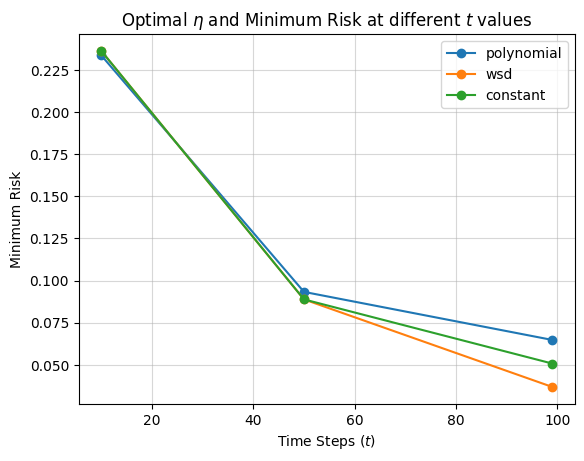

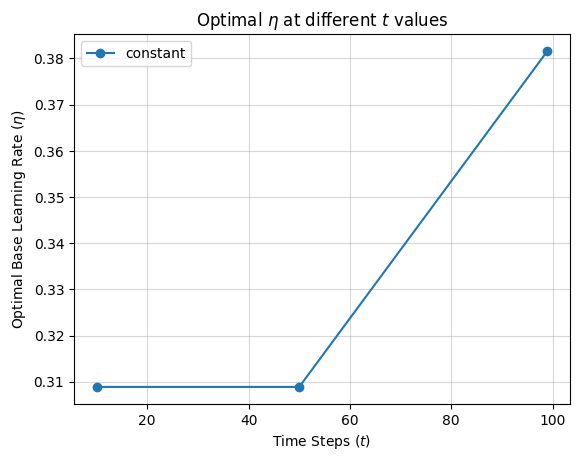

In [ ]:
risksSGD = computations_SGD.optimize_at_several_ts(x0, t_values=[10, 20, 30, 40, 50, 60, 70, 80, 99], plot=True, change_eta=False)


In [ ]:
risksSGD

{10: {'best_etas': {'polynomial': 0.47148663634573945,
   'wsd': 0.20235896477251575,
   'constant': 0.20235896477251575},
  'min_risks': {'polynomial': 0.4793065150361907,
   'wsd': 0.49146317094922404,
   'constant': 0.49146317094922404}},
 50: {'best_etas': {'polynomial': 1.0985411419875595,
   'wsd': 0.3088843596477482,
   'constant': 0.3088843596477482},
  'min_risks': {'polynomial': 0.2077713941598665,
   'wsd': 0.21444812976535715,
   'constant': 0.21444812976535715}},
 99: {'best_etas': {'polynomial': 1.0985411419875595,
   'wsd': 0.47148663634573945,
   'constant': 0.3816213407949357},
  'min_risks': {'polynomial': 0.1408557017874385,
   'wsd': 0.08321274398849549,
   'constant': 0.11465289704259195}}}